# Week 4 Lab: Position Sizing, Market Regimes & LLM Sentiment

**BUS 696: Generative AI in Finance**  
**Professor Jonathan Hersh**

---

## Learning Objectives

By the end of this lab, you will be able to:
1. Implement the **Kelly Criterion** and see why position sizing matters more than prediction accuracy
2. Understand why **hedge funds blow up** through the lens of the Kelly curve (LTCM, Amaranth, Archegos)
3. Simulate how **market regimes** break ML models trained in one environment


**Estimated time: 30–45 minutes**

---

## Part 1: Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Color palette
NAVY = '#1E2761'
CORAL = '#F96167'
TEAL = '#028090'
GOLD = '#F9A825'
GRAY = '#6c757d'

print('All libraries loaded!')

All libraries loaded!


---

## Part 2: The Kelly Criterion — Why Position Sizing > Prediction Accuracy

From the lecture, we learned that even a tiny edge (52% accuracy) can be hugely profitable — **if you size your bets correctly**. The Kelly Criterion tells you the optimal fraction of your bankroll to bet:

$$f^* = \frac{p \cdot b - q}{b}$$

Where:
- $p$ = probability of winning (e.g., 0.52)
- $q = 1 - p$ = probability of losing
- $b$ = odds (for even-money bets, $b = 1$)

For a 52% win rate with even odds: $f^* = 0.52 - 0.48 = 0.04$ (bet 4% of your capital each time)

Let's simulate this to see how dramatically position sizing affects outcomes.

In [2]:
# Simulate 1000 bets with a 52% edge
np.random.seed(42)
n_bets = 1000
win_prob = 0.52

# Generate outcomes: 1 = win, -1 = loss
outcomes = np.where(np.random.random(n_bets) < win_prob, 1, -1)

print(f'Simulated {n_bets} bets with {win_prob:.0%} win rate')
print(f'Actual wins: {(outcomes == 1).sum()} ({(outcomes == 1).mean():.1%})')
print(f'Actual losses: {(outcomes == -1).sum()} ({(outcomes == -1).mean():.1%})')

Simulated 1000 bets with 52% win rate
Actual wins: 525 (52.5%)
Actual losses: 475 (47.5%)


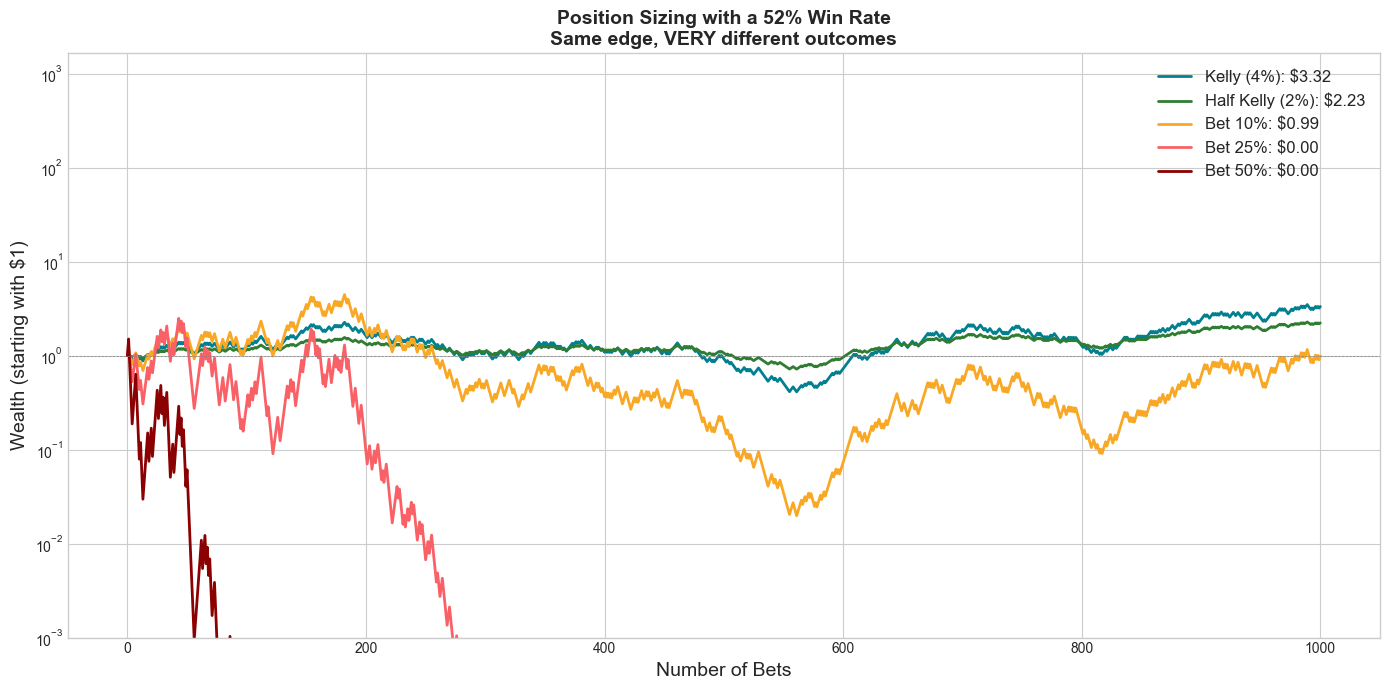

Key insight: With a 52% edge...
  - Kelly (4%) grows your wealth steadily
  - Half Kelly (2%) is safer but slower
  - Betting 25% or 50% leads to RUIN despite having an edge!

The model is only half the system. Position sizing is the other half.


In [3]:
def simulate_betting(outcomes, fraction):
    """Simulate wealth trajectory betting a fixed fraction of bankroll."""
    wealth = np.ones(len(outcomes) + 1)  # start with $1
    for i, outcome in enumerate(outcomes):
        wealth[i + 1] = wealth[i] * (1 + fraction * outcome)
    return wealth

# Try different bet sizes
fractions = {
    'Kelly (4%)': 0.04,
    'Half Kelly (2%)': 0.02,
    'Bet 10%': 0.10,
    'Bet 25%': 0.25,
    'Bet 50%': 0.50,
}

fig, ax = plt.subplots(figsize=(14, 7))

colors_list = [TEAL, '#2E7D32', GOLD, CORAL, '#8B0000']
for (name, frac), color in zip(fractions.items(), colors_list):
    wealth = simulate_betting(outcomes, frac)
    ax.plot(wealth, label=f'{name}: ${wealth[-1]:.2f}', linewidth=2, color=color)

ax.axhline(y=1, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel('Number of Bets', fontsize=14)
ax.set_ylabel('Wealth (starting with $1)', fontsize=14)
ax.set_title('Position Sizing with a 52% Win Rate\nSame edge, VERY different outcomes',
             fontweight='bold', fontsize=14)
ax.legend(fontsize=12)
ax.set_yscale('log')
ax.set_ylim(bottom=0.001)

plt.tight_layout()
plt.show()

print('Key insight: With a 52% edge...')
print('  - Kelly (4%) grows your wealth steadily')
print('  - Half Kelly (2%) is safer but slower')
print('  - Betting 25% or 50% leads to RUIN despite having an edge!')
print('\nThe model is only half the system. Position sizing is the other half.')

### The Kelly Curve: There's a Sweet Spot

Let's plot the expected growth rate as a function of bet size. Betting too much is *worse* than betting too little.

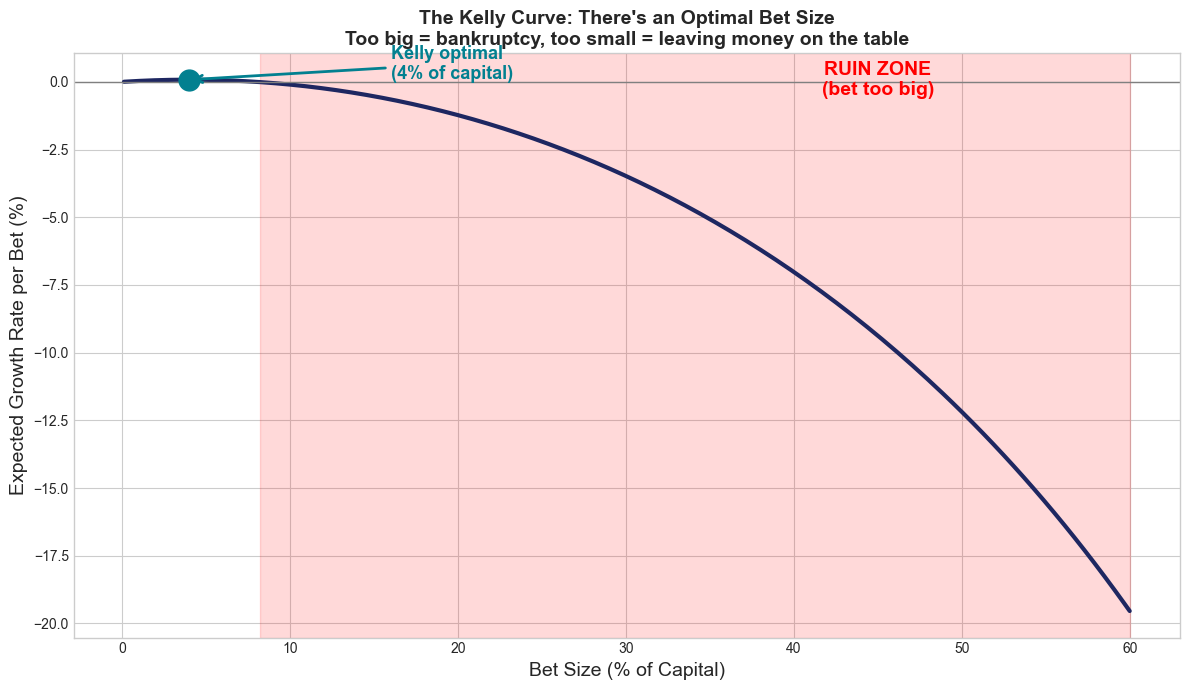

Kelly fraction for 52% win rate: 4.00%
Expected growth per bet at Kelly: 0.0800%

Breakeven bet size: ~8% — anything above this and you lose money!

This is why Renaissance Technologies reportedly uses ~Half Kelly.
Even with a massive edge, they bet conservatively.


In [4]:
# Expected log growth rate for different bet fractions
fracs = np.linspace(0.001, 0.60, 200)
p = 0.52
q = 1 - p

# Expected log growth rate: p * ln(1+f) + q * ln(1-f)
growth_rates = p * np.log(1 + fracs) + q * np.log(1 - fracs)

# Kelly optimal
kelly_f = p - q  # = 0.04 for even-money bets
kelly_g = p * np.log(1 + kelly_f) + q * np.log(1 - kelly_f)

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(fracs * 100, growth_rates * 100, linewidth=3, color=NAVY)
ax.axhline(y=0, color='gray', linewidth=1)

# Mark Kelly optimal
ax.plot(kelly_f * 100, kelly_g * 100, 'o', color=TEAL, markersize=15, zorder=5)
ax.annotate(f'Kelly optimal\n({kelly_f:.0%} of capital)',
            xy=(kelly_f * 100, kelly_g * 100),
            xytext=(kelly_f * 100 + 12, kelly_g * 100 + 0.01),
            fontsize=13, fontweight='bold', color=TEAL,
            arrowprops=dict(arrowstyle='->', color=TEAL, lw=2))

# Mark the ruin zone
ruin_start = fracs[growth_rates < 0][0] * 100 if any(growth_rates < 0) else 60
ax.axvspan(ruin_start, 60, alpha=0.15, color='red')
ax.text(45, -0.5, 'RUIN ZONE\n(bet too big)', fontsize=14,
        color='red', fontweight='bold', ha='center')

ax.set_xlabel('Bet Size (% of Capital)', fontsize=14)
ax.set_ylabel('Expected Growth Rate per Bet (%)', fontsize=14)
ax.set_title('The Kelly Curve: There\'s an Optimal Bet Size\n'
             'Too big = bankruptcy, too small = leaving money on the table',
             fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

print(f'Kelly fraction for 52% win rate: {kelly_f:.2%}')
print(f'Expected growth per bet at Kelly: {kelly_g*100:.4f}%')
print(f'\nBreakeven bet size: ~{ruin_start:.0f}% \u2014 anything above this and you lose money!')
print('\nThis is why Renaissance Technologies reportedly uses ~Half Kelly.')
print('Even with a massive edge, they bet conservatively.')

---

### Why Hedge Funds Blow Up: The Kelly Perspective

Most hedge fund blow-ups share a common pattern: **they bet to the right of the Kelly optimum.**

The Kelly formula says:

$$f^* \approx \frac{\text{edge}}{\text{variance}}$$

When your edge is small and variance is high, the optimal bet size is **tiny**. But hedge funds face institutional pressure:
- Investors demand 20%+ returns
- Fees require large AUM and high returns
- Relative performance pressure pushes toward bigger bets

So they use **leverage** to amplify tiny edges — which moves them rightward on the Kelly curve, into the ruin zone.

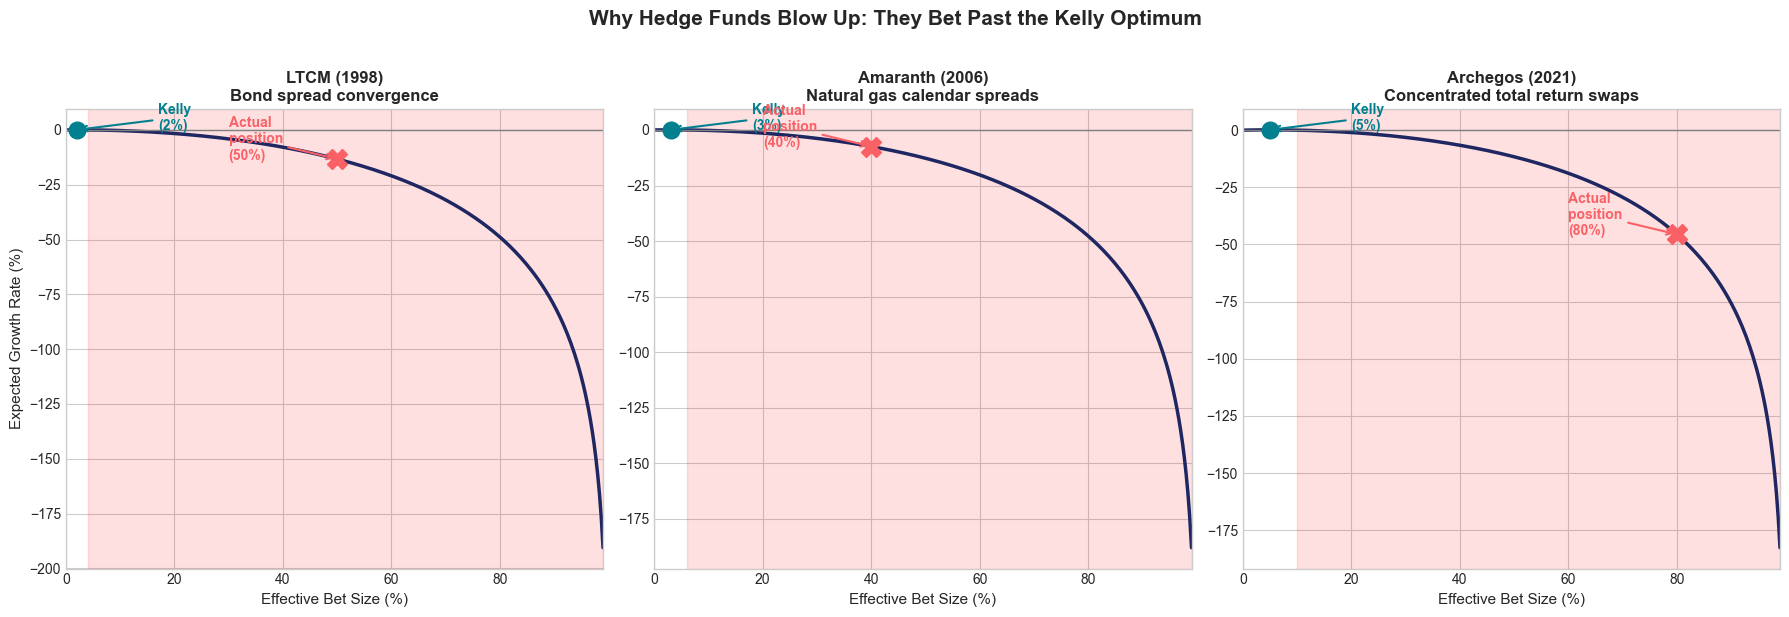

The pattern is always the same:
  1. Fund has a real edge (green dot = Kelly optimal)
  2. Leverage amplifies position sizes far past Kelly (red X)
  3. In the ruin zone, even with a positive edge, you go to zero
  4. They look brilliant for years... then one bad sequence wipes them out


In [5]:
# Simulate three famous blow-ups through the Kelly lens
np.random.seed(42)

# Each fund had a real edge, but used too much leverage
blowup_cases = {
    'LTCM (1998)': {
        'edge': 0.02,      # ~2% edge on bond convergence trades
        'leverage': 25,     # 25x leverage
        'description': 'Bond spread convergence',
        'kelly_optimal': 0.02,  # should have bet ~2% of capital
        'actual_bet': 0.50,     # effectively betting ~50% per position with leverage
    },
    'Amaranth (2006)': {
        'edge': 0.03,      # ~3% edge on natural gas spreads
        'leverage': 8,
        'description': 'Natural gas calendar spreads',
        'kelly_optimal': 0.03,
        'actual_bet': 0.40,
    },
    'Archegos (2021)': {
        'edge': 0.05,      # ~5% edge (concentrated stock picks)
        'leverage': 5,
        'description': 'Concentrated total return swaps',
        'kelly_optimal': 0.05,
        'actual_bet': 0.80,
    },
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (fund_name, info) in zip(axes, blowup_cases.items()):
    edge = info['edge']
    p_fund = 0.5 + edge / 2  # convert edge to win probability
    q_fund = 1 - p_fund
    
    # Kelly curve for this fund
    fracs_fund = np.linspace(0.001, 0.99, 300)
    growth_fund = p_fund * np.log(1 + fracs_fund) + q_fund * np.log(1 - fracs_fund)
    
    ax.plot(fracs_fund * 100, growth_fund * 100, linewidth=2.5, color=NAVY)
    ax.axhline(y=0, color='gray', linewidth=1)
    
    # Kelly optimal point
    kelly_opt = info['kelly_optimal']
    kelly_growth = p_fund * np.log(1 + kelly_opt) + q_fund * np.log(1 - kelly_opt)
    ax.plot(kelly_opt * 100, kelly_growth * 100, 'o', color=TEAL, markersize=12, zorder=5)
    ax.annotate(f'Kelly\n({kelly_opt:.0%})',
                xy=(kelly_opt * 100, kelly_growth * 100),
                xytext=(kelly_opt * 100 + 15, kelly_growth * 100 + 0.05),
                fontsize=10, fontweight='bold', color=TEAL,
                arrowprops=dict(arrowstyle='->', color=TEAL, lw=1.5))
    
    # Where they actually were
    actual = info['actual_bet']
    actual_growth = p_fund * np.log(1 + actual) + q_fund * np.log(1 - actual)
    ax.plot(actual * 100, actual_growth * 100, 'X', color=CORAL, markersize=15, zorder=5)
    ax.annotate(f'Actual\nposition\n({actual:.0%})',
                xy=(actual * 100, actual_growth * 100),
                xytext=(actual * 100 - 20, actual_growth * 100 - 0.3),
                fontsize=10, fontweight='bold', color=CORAL,
                arrowprops=dict(arrowstyle='->', color=CORAL, lw=1.5))
    
    # Shade ruin zone
    ruin_idx = np.where(growth_fund < 0)[0]
    if len(ruin_idx) > 0:
        ruin_x = fracs_fund[ruin_idx[0]] * 100
        ax.axvspan(ruin_x, 99, alpha=0.12, color='red')
    
    ax.set_title(f'{fund_name}\n{info["description"]}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Effective Bet Size (%)', fontsize=11)
    if ax == axes[0]:
        ax.set_ylabel('Expected Growth Rate (%)', fontsize=11)
    ax.set_xlim(0, 99)

fig.suptitle('Why Hedge Funds Blow Up: They Bet Past the Kelly Optimum',
             fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print('The pattern is always the same:')
print('  1. Fund has a real edge (green dot = Kelly optimal)')
print('  2. Leverage amplifies position sizes far past Kelly (red X)')
print('  3. In the ruin zone, even with a positive edge, you go to zero')
print('  4. They look brilliant for years... then one bad sequence wipes them out')

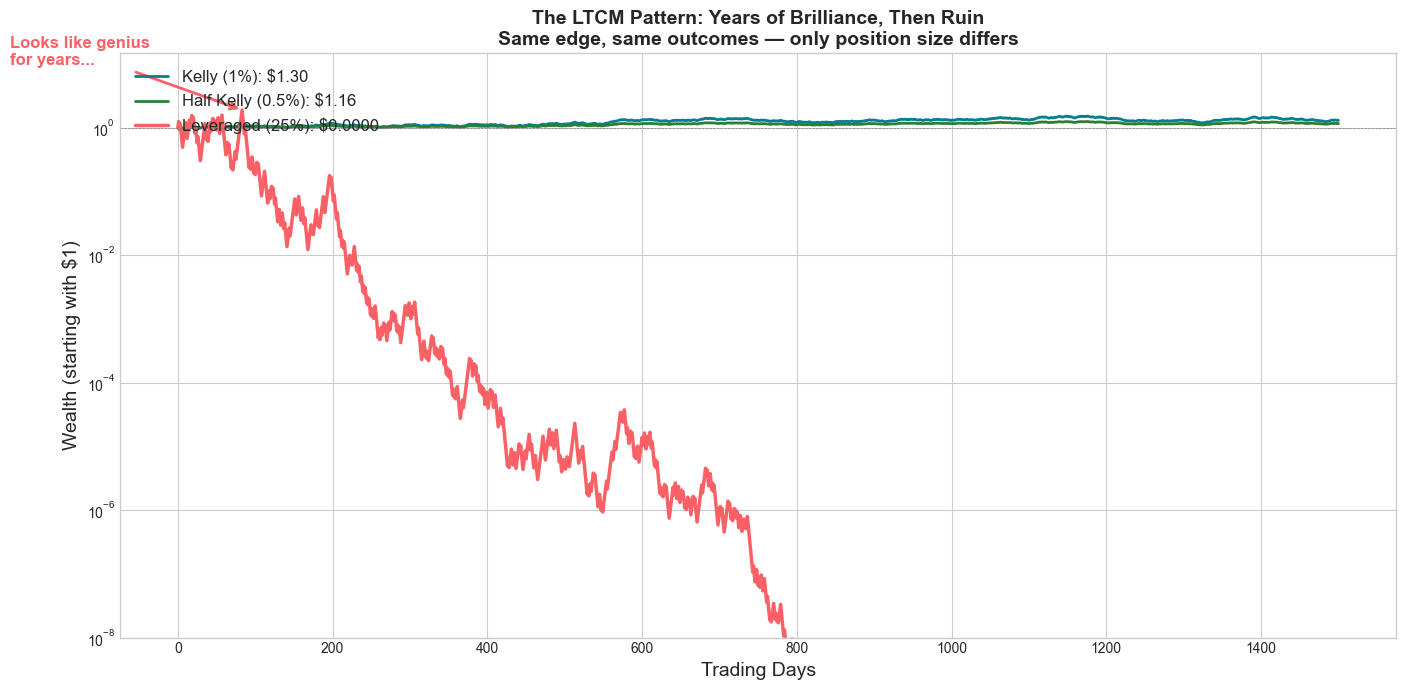

The paradox of overbetting:
  - Kelly investors survive forever, but look conservative
  - Leveraged investors look brilliant for years, then disappear
  - The market systematically rewards temporary overbetting

Warren Buffett's approach resembles fractional Kelly:
  - Large bets only when edge is huge
  - Otherwise holds cash
  - Avoids leverage
  - This is why he compounds for decades.


In [6]:
# Simulate LTCM-style trajectory: years of steady gains, then sudden collapse
np.random.seed(7)

n_days = 1500  # ~6 years of trading
edge = 0.01  # small daily edge
p_ltcm = 0.5 + edge / 2

outcomes_ltcm = np.where(np.random.random(n_days) < p_ltcm, 1, -1)

# Kelly says bet ~1% of capital
kelly_path = simulate_betting(outcomes_ltcm, fraction=0.01)
half_kelly_path = simulate_betting(outcomes_ltcm, fraction=0.005)

# But LTCM effectively bet ~25% with leverage
leveraged_path = simulate_betting(outcomes_ltcm, fraction=0.25)

fig, ax = plt.subplots(figsize=(14, 7))

days = np.arange(n_days + 1)
ax.plot(days, kelly_path, label=f'Kelly (1%): ${kelly_path[-1]:.2f}', 
        color=TEAL, linewidth=2)
ax.plot(days, half_kelly_path, label=f'Half Kelly (0.5%): ${half_kelly_path[-1]:.2f}', 
        color='#2E7D32', linewidth=2)
ax.plot(days, leveraged_path, label=f'Leveraged (25%): ${leveraged_path[-1]:.4f}', 
        color=CORAL, linewidth=2.5)

ax.axhline(y=1, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel('Trading Days', fontsize=14)
ax.set_ylabel('Wealth (starting with $1)', fontsize=14)
ax.set_title('The LTCM Pattern: Years of Brilliance, Then Ruin\n'
             'Same edge, same outcomes \u2014 only position size differs',
             fontweight='bold', fontsize=14)
ax.legend(fontsize=12, loc='upper left')
ax.set_yscale('log')
ax.set_ylim(bottom=1e-8)

# Annotate the collapse
# Find where leveraged path peaks
peak_idx = np.argmax(leveraged_path)
if peak_idx > 0 and peak_idx < n_days:
    ax.annotate('Looks like genius\nfor years...',
                xy=(peak_idx, leveraged_path[peak_idx]),
                xytext=(peak_idx - 300, leveraged_path[peak_idx] * 5),
                fontsize=12, fontweight='bold', color=CORAL,
                arrowprops=dict(arrowstyle='->', color=CORAL, lw=2))

plt.tight_layout()
plt.show()

print('The paradox of overbetting:')
print('  - Kelly investors survive forever, but look conservative')
print('  - Leveraged investors look brilliant for years, then disappear')
print('  - The market systematically rewards temporary overbetting')
print(f'\nWarren Buffett\'s approach resembles fractional Kelly:')
print('  - Large bets only when edge is huge')
print('  - Otherwise holds cash')
print('  - Avoids leverage')
print('  - This is why he compounds for decades.')

### What If Your Edge Is Bigger?

The lecture mentioned that Renaissance Technologies' Medallion Fund achieved ~66% annual returns. Suppose a model has 55% accuracy (instead of 52%).

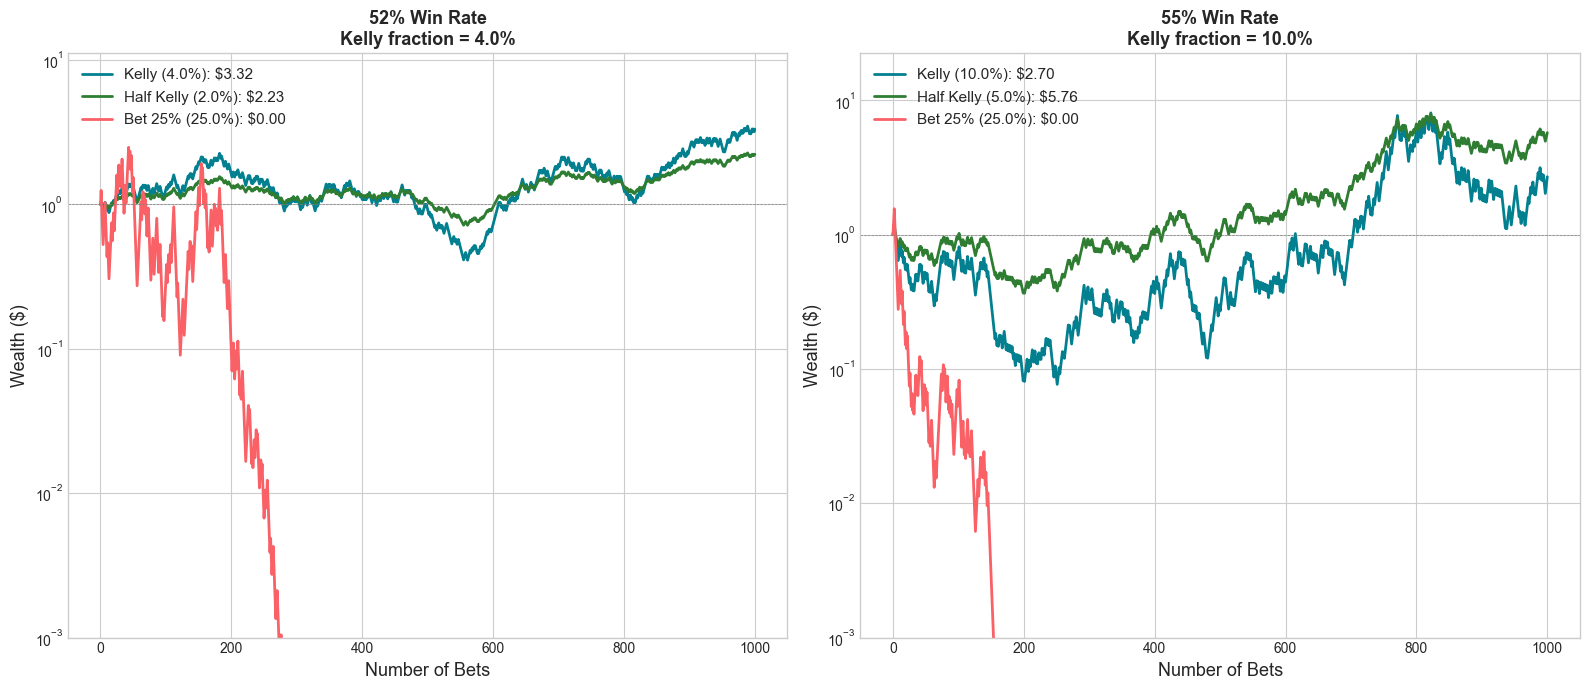

A 3% increase in accuracy (52% → 55%) is ENORMOUSLY more valuable!
  Kelly fraction goes from 4% to 10% — you can bet 2.5x more per trade
  Growth rate roughly quadruples

This is why hedge funds spend billions on data and talent
  — even a tiny improvement in accuracy compounds into massive wealth.


In [7]:
# Compare 52% vs 55% edge — how much more valuable is 3% more accuracy?
np.random.seed(42)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (win_rate, title) in zip(axes, [(0.52, '52% Win Rate'), (0.55, '55% Win Rate')]):
    outcomes_edge = np.where(np.random.random(1000) < win_rate, 1, -1)
    kelly_frac = win_rate - (1 - win_rate)
    
    for name, frac, color in [('Kelly', kelly_frac, TEAL), 
                               ('Half Kelly', kelly_frac/2, '#2E7D32'),
                               ('Bet 25%', 0.25, CORAL)]:
        wealth = simulate_betting(outcomes_edge, frac)
        ax.plot(wealth, label=f'{name} ({frac:.1%}): ${wealth[-1]:.2f}', 
                linewidth=2, color=color)
    
    ax.axhline(y=1, color='gray', linewidth=0.5, linestyle='--')
    ax.set_xlabel('Number of Bets', fontsize=13)
    ax.set_ylabel('Wealth ($)', fontsize=13)
    ax.set_title(f'{title}\nKelly fraction = {kelly_frac:.1%}', fontweight='bold', fontsize=13)
    ax.legend(fontsize=11)
    ax.set_yscale('log')
    ax.set_ylim(bottom=0.001)

plt.tight_layout()
plt.show()

print('A 3% increase in accuracy (52% \u2192 55%) is ENORMOUSLY more valuable!')
print(f'  Kelly fraction goes from 4% to 10% \u2014 you can bet 2.5x more per trade')
print(f'  Growth rate roughly quadruples')
print(f'\nThis is why hedge funds spend billions on data and talent')
print(f'  \u2014 even a tiny improvement in accuracy compounds into massive wealth.')

---

## Part 3: Market Regimes — Why Models Break

The lecture showed that markets move through **regimes**: bull markets, crashes, recovery periods, rate hike cycles. A model trained during a bull market may fail completely during a crash.

Let's see this with real data by comparing how a simple momentum signal performs across different market environments.

In [8]:
# Download 20 years of S&P 500 data to see multiple regimes
spy = yf.download('SPY', start='2005-01-01')
spy.columns = spy.columns.get_level_values(0)
spy['Log_Return'] = np.log(spy['Close'] / spy['Close'].shift(1))
spy['Volatility'] = spy['Log_Return'].rolling(60).std() * np.sqrt(252)  # annualized
spy = spy.dropna()

print(f'SPY data: {spy.index[0].date()} to {spy.index[-1].date()}')
print(f'{len(spy)} trading days')

[*********************100%***********************]  1 of 1 completed

SPY data: 2005-03-31 to 2026-03-04
5265 trading days


In [9]:
# Define market regimes based on rolling volatility
spy['Regime'] = pd.cut(spy['Volatility'],
                       bins=[0, 0.15, 0.25, np.inf],
                       labels=['Calm (<15%)', 'Normal (15-25%)', 'Crisis (>25%)'])

# Simple momentum signal: buy if 20-day return > 0, sell otherwise
spy['Momentum_Signal'] = np.sign(spy['Log_Return'].rolling(20).mean())
spy['Strategy_Return'] = spy['Momentum_Signal'].shift(1) * spy['Log_Return']

# Performance by regime
print('Momentum Strategy Performance by Market Regime')
print('=' * 60)

regime_stats = spy.dropna().groupby('Regime').agg(
    days=('Log_Return', 'count'),
    market_return=('Log_Return', lambda x: x.mean() * 252),
    strategy_return=('Strategy_Return', lambda x: x.mean() * 252),
    market_vol=('Log_Return', lambda x: x.std() * np.sqrt(252)),
    hit_rate=('Strategy_Return', lambda x: (x > 0).mean())
)

for regime in regime_stats.index:
    row = regime_stats.loc[regime]
    print(f'\n{regime}:')
    print(f'  Days: {row["days"]:.0f}')
    print(f'  Market return (ann.): {row["market_return"]:.1%}')
    print(f'  Strategy return (ann.): {row["strategy_return"]:.1%}')
    print(f'  Hit rate: {row["hit_rate"]:.1%}')

Momentum Strategy Performance by Market Regime

Calm (<15%):
  Days: 3190
  Market return (ann.): 12.1%
  Strategy return (ann.): 0.1%
  Hit rate: 52.9%

Normal (15-25%):
  Days: 1470
  Market return (ann.): 7.3%
  Strategy return (ann.): 8.9%
  Hit rate: 51.7%

Crisis (>25%):
  Days: 585
  Market return (ann.): 8.9%
  Strategy return (ann.): 10.4%
  Hit rate: 48.9%


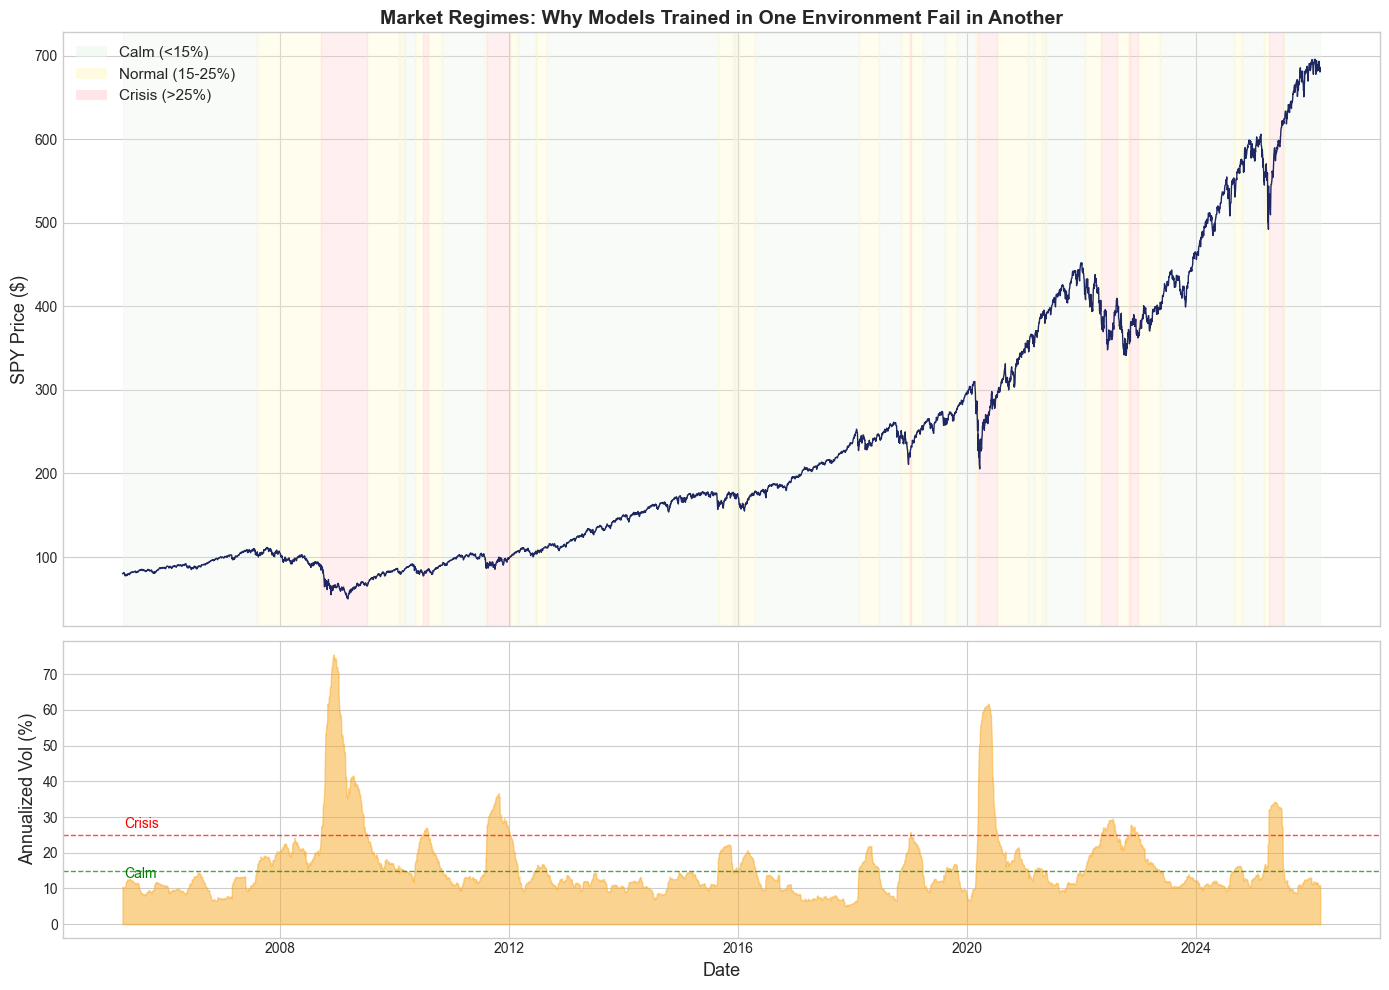

A model trained during the calm green periods (2013–2019)
would have no idea what to do during the red crisis periods (2008, 2020).
This is non-stationarity — the data-generating process itself changes.


In [10]:
# Visualize: regime map + strategy performance
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]})

# Top: Price with regime coloring
ax = axes[0]
ax.plot(spy.index, spy['Close'], color=NAVY, linewidth=1)

# Color background by regime
regime_colors = {'Calm (<15%)': '#E8F5E9', 'Normal (15-25%)': '#FFF9C4', 'Crisis (>25%)': '#FFCDD2'}
for regime, color in regime_colors.items():
    mask = spy['Regime'] == regime
    if mask.any():
        changes = mask.astype(int).diff().fillna(0)
        starts = spy.index[changes == 1]
        ends = spy.index[changes == -1]
        if mask.iloc[0]:
            starts = starts.insert(0, spy.index[0])
        if mask.iloc[-1]:
            ends = ends.append(pd.DatetimeIndex([spy.index[-1]]))
        for s, e in zip(starts[:len(ends)], ends[:len(starts)]):
            ax.axvspan(s, e, alpha=0.3, color=color)

ax.set_ylabel('SPY Price ($)', fontsize=13)
ax.set_title('Market Regimes: Why Models Trained in One Environment Fail in Another',
             fontweight='bold', fontsize=14)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, alpha=0.5, label=r) for r, c in regime_colors.items()]
ax.legend(handles=legend_elements, fontsize=11, loc='upper left')

# Bottom: Rolling volatility
ax = axes[1]
ax.fill_between(spy.index, 0, spy['Volatility'] * 100, color=GOLD, alpha=0.5)
ax.axhline(y=15, color='green', linewidth=1, linestyle='--', alpha=0.7)
ax.axhline(y=25, color='red', linewidth=1, linestyle='--', alpha=0.7)
ax.set_ylabel('Annualized Vol (%)', fontsize=13)
ax.set_xlabel('Date', fontsize=13)
ax.text(spy.index[10], 13, 'Calm', color='green', fontsize=10)
ax.text(spy.index[10], 27, 'Crisis', color='red', fontsize=10)

plt.tight_layout()
plt.show()

print('A model trained during the calm green periods (2013\u20132019)')
print('would have no idea what to do during the red crisis periods (2008, 2020).')
print('This is non-stationarity \u2014 the data-generating process itself changes.')

In [12]:
# Train in calm, test in crisis: demonstrate regime-dependent failure
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Engineer simple features on SPY
spy_feat = spy[['Close', 'Log_Return']].copy()
for lag in range(1, 6):
    spy_feat[f'ret_lag{lag}'] = spy_feat['Log_Return'].shift(lag)
spy_feat['vol_20'] = spy_feat['Log_Return'].rolling(20).std()
spy_feat['mom_20'] = spy_feat['Log_Return'].rolling(20).mean()
spy_feat['target'] = (spy_feat['Log_Return'] > 0).astype(int)
spy_feat = spy_feat.dropna()

feature_cols = [c for c in spy_feat.columns if c not in ['Close', 'Log_Return', 'target']]

# Period definitions
calm_train = spy_feat['2013':'2019']
crisis_test = spy_feat['2020-01':'2020-06']  # COVID crash
crisis_train = spy_feat['2007':'2009']        # GFC period

scaler = StandardScaler()

# Model 1: Trained in calm, tested in crisis
X_calm = scaler.fit_transform(calm_train[feature_cols])
y_calm = calm_train['target']
lr_calm = LogisticRegression(max_iter=1000, random_state=42).fit(X_calm, y_calm)

X_crisis_test = scaler.transform(crisis_test[feature_cols])
acc_calm_to_crisis = accuracy_score(crisis_test['target'], lr_calm.predict(X_crisis_test))

# Model 2: Trained in crisis, tested in crisis
scaler2 = StandardScaler()
X_crisis_train = scaler2.fit_transform(crisis_train[feature_cols])
y_crisis_train = crisis_train['target']
lr_crisis = LogisticRegression(max_iter=1000, random_state=42).fit(X_crisis_train, y_crisis_train)

X_crisis_test2 = scaler2.transform(crisis_test[feature_cols])
acc_crisis_to_crisis = accuracy_score(crisis_test['target'], lr_crisis.predict(X_crisis_test2))

# Model 3: Trained in calm, tested in calm
calm_test = spy_feat['2023':'2023']
X_calm_test = scaler.transform(calm_test[feature_cols])
acc_calm_to_calm = accuracy_score(calm_test['target'], lr_calm.predict(X_calm_test))

print('Regime Mismatch Experiment')
print('=' * 55)
print(f'\nTrained in CALM (2013-19), tested in CALM (2023):')
print(f'  Accuracy: {acc_calm_to_calm:.1%}')
print(f'\nTrained in CALM (2013-19), tested in CRISIS (2020):')
print(f'  Accuracy: {acc_calm_to_crisis:.1%}')
print(f'\nTrained in CRISIS (2007-09), tested in CRISIS (2020):')
print(f'  Accuracy: {acc_crisis_to_crisis:.1%}')
print(f'\nLesson: Models trained in one regime struggle in another.')
print(f'This is why walk-forward validation is essential.')

Regime Mismatch Experiment

Trained in CALM (2013-19), tested in CALM (2023):
  Accuracy: 57.6%

Trained in CALM (2013-19), tested in CRISIS (2020):
  Accuracy: 64.0%

Trained in CRISIS (2007-09), tested in CRISIS (2020):
  Accuracy: 60.8%

Lesson: Models trained in one regime struggle in another.
This is why walk-forward validation is essential.


---

## Key Takeaways

1. **Position sizing matters more than accuracy** — the Kelly Criterion shows how a 52% edge can build wealth OR cause ruin depending on bet size
2. **Hedge funds blow up by overbetting** — LTCM, Amaranth, and Archegos all had real edges but used leverage to move past the Kelly optimum into the ruin zone
3. **Half Kelly is the industry standard** — even Renaissance Technologies bets conservatively; Kelly investors survive forever but look boring
4. **Market regimes break models** — a model trained in calm markets will fail in a crisis (non-stationarity)
5. **LLMs can extract tradeable sentiment from news** — but the effect is stronger for less efficient (smaller) stocks
6. **Alpha decays as adoption grows** — the Grossman-Stiglitz paradox means every edge has a half-life
7. **AI's durable value** is less about predicting direction and more about risk management, execution, and processing information at superhuman scale